<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>

## Define Problem Statement and Objectives

##Context:
The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.


##Objective:
The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected.

Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:

1. Do the users spend more time on the new landing page than on the existing landing page?
2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
3. Does the converted status depend on the preferred language?
Is the time spent on the new page the same for the different language users?

##Data Dictionary:
The data contains information regarding the interaction of users in both groups with the two versions of the landing page.

1. user_id - Unique user ID of the person visiting the website
2. group - Whether the user belongs to the first group (control) or the second group (treatment)
3. landing_page - Whether the landing page is new or old
4. time_spent_on_the_page - Time (in minutes) spent by the user on the landing page
5. converted - Whether the user gets converted to a subscriber of the news portal or not
6. language_preferred - language chosen by the user to view the landing page

## Import all the necessary libraries

In [4]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
#import the important packages
import pandas as pd #library used for data manipulation and analysis
import numpy as np # library used for working with arrays.
import matplotlib.pyplot as plt # library for plots and visualisations
import seaborn as sns # library for visualisations
%matplotlib inline

import scipy.stats as stats # this library contains a large number of probability distributions as well as a growing library of statistical functions.
from scipy.stats import chi2_contingency

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/UT Austin/abtest.csv'

data = pd.read_csv(file_path)
df=data.copy()

Mounted at /content/drive


## Reading the Data into a DataFrame

In [5]:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [6]:
# View the first 5 rows

df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [7]:
# View the last 5 rows
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [8]:
# Check number of rows and columns
df.shape

(100, 6)

In [9]:
# Check the datatypes of columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [10]:
# check for statistical summary
df.describe()

,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000


#Observations: The mean (5.38) is slightly lower than the median (5.42), suggesting a slight left skew in the distribution. However, the difference is very small and it shouldn't affected our analysis. We can expect that the histogram should appear approximately symmetric, but we will verify it in further analysis.

In [11]:
# Check for missing values
display(df.isnull().sum())

# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


Number of duplicate rows: 0


## Observations:
No missing values and no duplocates in the data.

In [12]:
# Check if there is any mismatch in the group and landing_page
pd.crosstab(df['group'],df['landing_page'])

landing_page,new,old
group,,
control,0,50
treatment,50,0


### Observations:

In the control group: o users saw new pages and 50 users saw old page.
In the treatment group: 50 users saw new pages and 0 users saw old page.

These told us that there is no mismatch in the data and we can perform A/B testing.

### Univariate Analysis: analyze individual variable to see their distributions, to detect issues and to get some insights

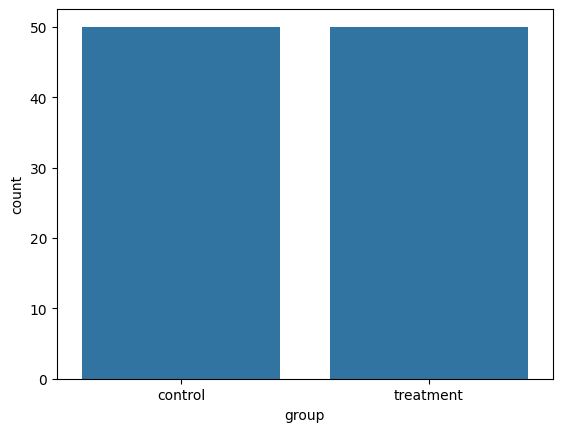

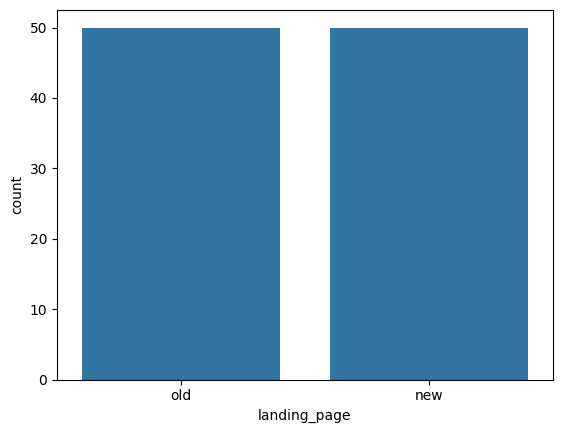

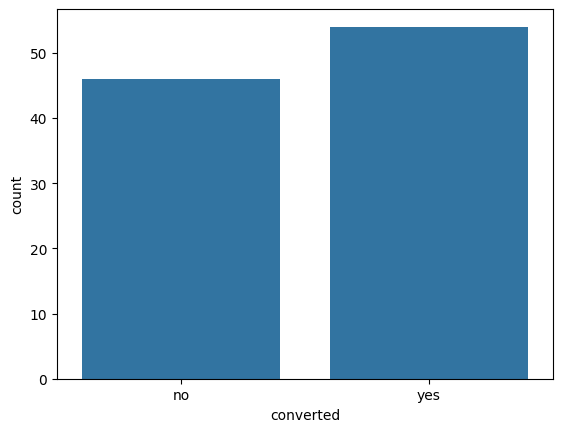

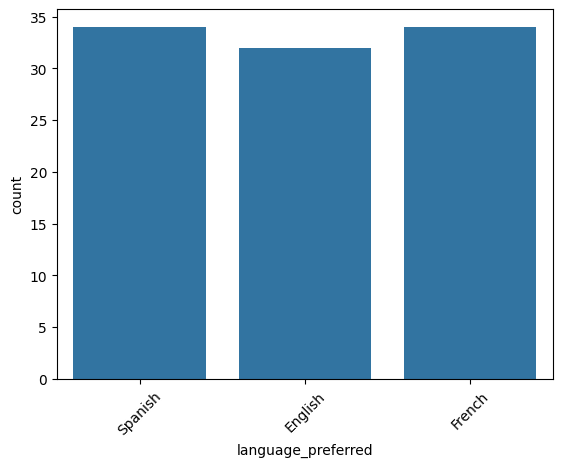

In [13]:
# Categorical variables
sns.countplot(data=df, x='group')
plt.show()

sns.countplot(data=df, x='landing_page')
plt.show()

sns.countplot(data=df, x='converted')
plt.show()

sns.countplot(data=df, x='language_preferred')
plt.xticks(rotation=45)
plt.show()

## Observations: basically, these columns are evenly spreaded. In the conversion, there were slighly more people who converted than the ones who stayed. Among languages, the number of people who chose either Spanish or French is more than the number of people who chose English.

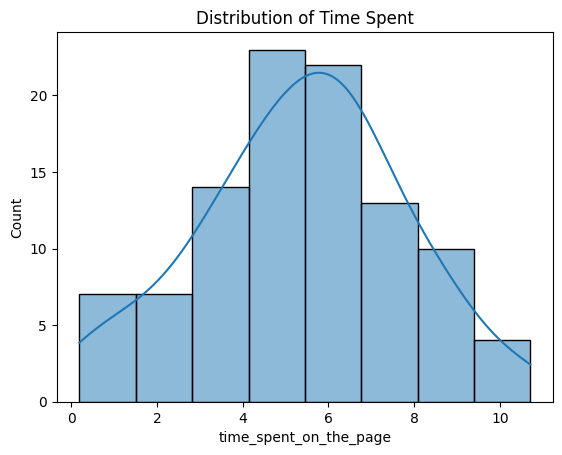

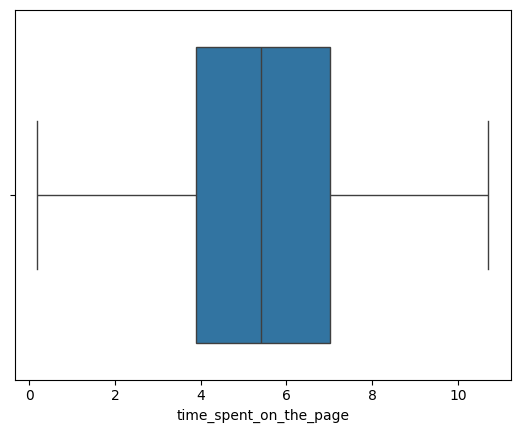

In [14]:
# Numerical variable

df['time_spent_on_the_page'].describe()
sns.histplot(df['time_spent_on_the_page'], kde=True)
plt.title('Distribution of Time Spent')
plt.show()

sns.boxplot(data=df, x='time_spent_on_the_page')
plt.show()

## Observations: The peak is around 5-7 minutes and the range falls between 0-11 minutes.The distribution looks close to normal distribution and there are no extreme outliers so the data is suitable for further statistical analysis.

### Bivariate Analysis

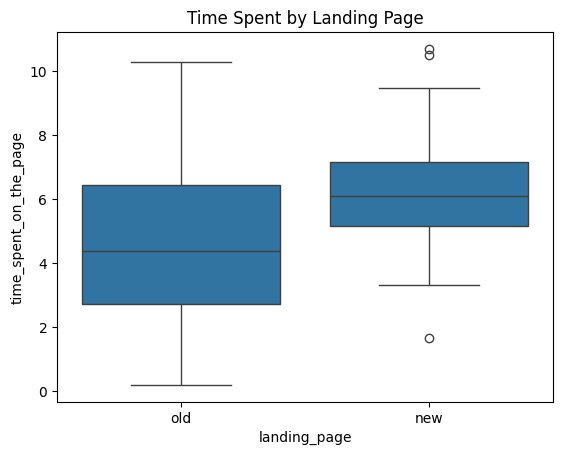

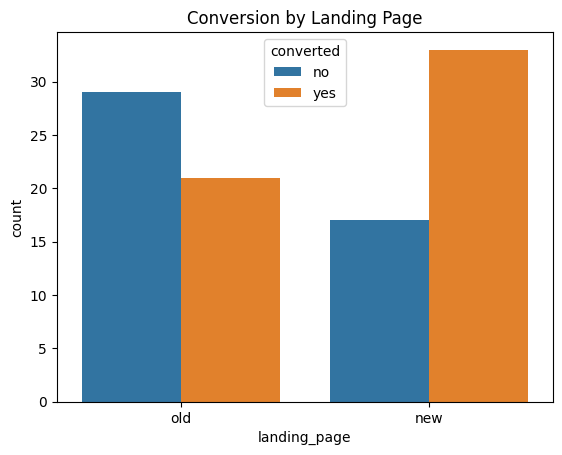

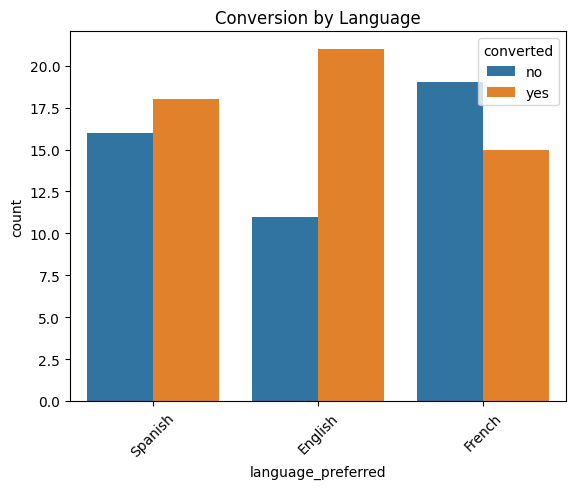

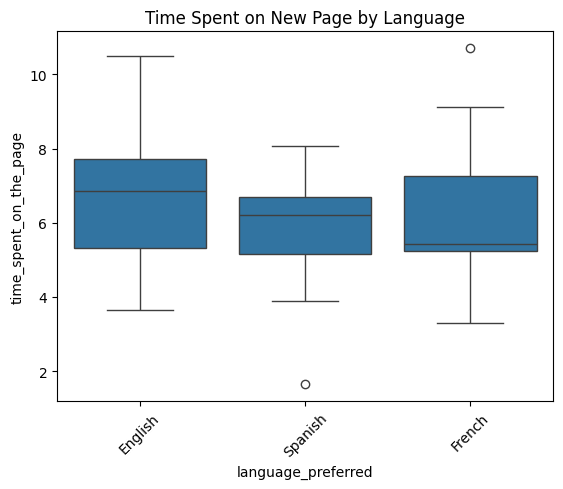

In [15]:
# 1. Time spent vs landing page
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title('Time Spent by Landing Page')
plt.show()

# 2. Conversion vs landing page
sns.countplot(data=df, x='landing_page', hue='converted')
plt.title('Conversion by Landing Page')
plt.show()

# 3. Conversion vs language
sns.countplot(data=df, x='language_preferred', hue='converted')
plt.title('Conversion by Language')
plt.xticks(rotation=45)
plt.show()

# 4. Time spent vs language (NEW PAGE ONLY)
new_df = df[df['landing_page'] == 'new']

sns.boxplot(data=new_df, x='language_preferred', y='time_spent_on_the_page')
plt.title('Time Spent on New Page by Language')
plt.xticks(rotation=45)
plt.show()

Based on the bivariate analysis plots, here's a summary of the findings:

*   **Time spent vs landing page:** The boxplot clearly suggests that users generally spend more time on the 'new' landing page compared to the 'old' one. The median time spent on the new page is visibly higher, but the interquartile range (IQR) for the old page indicates longer engagement times. There are few outliers in the new landing page but these shouldn't significantly skew the general observation.

*   **Conversion vs landing page:** The countplot shows a distinct difference in conversions. The 'new' landing page resulted in a higher count of converted users ('yes') and a lower count of non-converted users ('no') compared to the 'old' landing page. This indicates a higher conversion rate for the new page.

*   **Conversion vs language:** The countplot for conversion by language shows that all three language groups (English, Spanish, French) have users who converted and users who did not. While there might be slight numerical differences in the counts, to determine if the conversion status depends on the preferred language, we would need to do further statistical analysis. Visually, English and Spanish users have higher conversion than French users.

*   **Time spent on New Page by Language:** The boxplot for time spent on the *new* page, broken down by language, reveals that users across all three languages (English, Spanish, French) spent comparable amounts of time. The medians and interquartile ranges are quite similar for all language groups, suggesting that language preference on the new page does not lead to significant differences in time spent.But we can still see that on average, English and Spanish users spent more time on the new page than French users.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

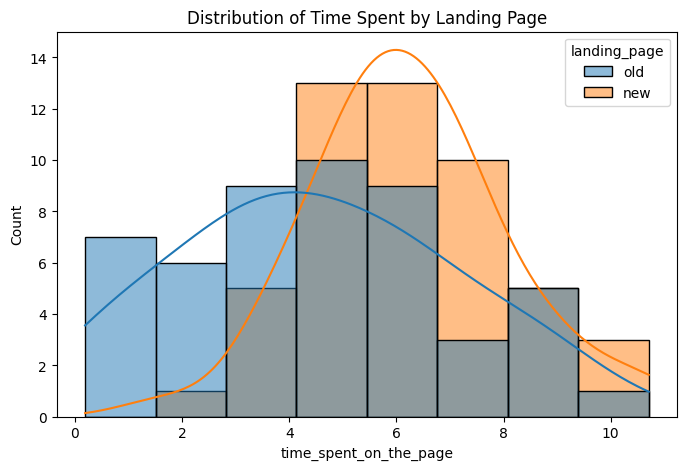

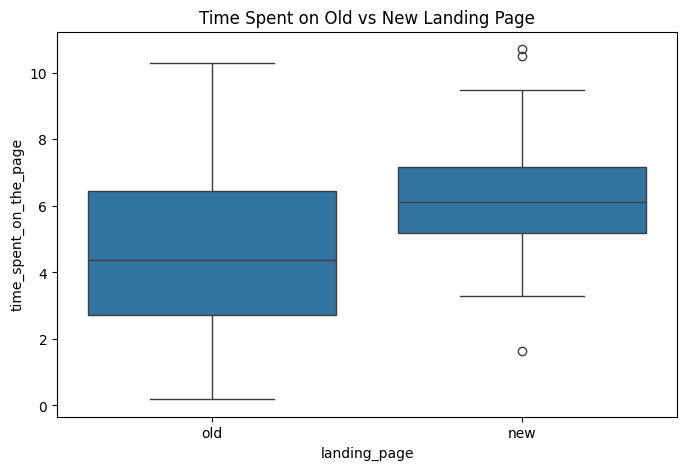

In [16]:

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='time_spent_on_the_page', hue='landing_page', kde=True)
plt.title("Distribution of Time Spent by Landing Page")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title("Time Spent on Old vs New Landing Page")
plt.show()

### Step 1: Define the null and alternate hypotheses

Let:
*   mu_new= mean time spent on the new landing pages
*   mu_old = mean time spent on the old landing pages

*   mu_new <= mu_old
*   mu_new > mu_old

### Step 2: Select Appropriate test

I chose t test since:
1. population standard devision is unknown.
2. The data (time spent) is continuous
3. compare 2 groups

But before I perform t test, I wll test for normality and equality (Levene) to make sure t test is appropriate.

### Step 3: Decide the significance level

We set that alpha is equal to 0.05, meaning that we accept of 5% of being wrong

### Step 4: Collect and prepare data

In [17]:

# create two groups
old_page = df[df['landing_page'] == 'old']['time_spent_on_the_page']
new_page = df[df['landing_page'] == 'new']['time_spent_on_the_page']

# check basic info
print("Old page sample size:", len(old_page))
print("New page sample size:", len(new_page))

print("Old page mean:", old_page.mean())
print("New page mean:", new_page.mean())
print("Old page standard deviation:", old_page.std())
print("New page standard deviation:", new_page.std())

Old page sample size: 50
New page sample size: 50
Old page mean: 4.532400000000001
New page mean: 6.2232
Old page standard deviation: 2.581974849306046
New page standard deviation: 1.8170310387878263


In [38]:
# test for normality
from scipy.stats import shapiro

old_page = df[df['landing_page'] == 'old']['time_spent_on_the_page']
new_page = df[df['landing_page'] == 'new']['time_spent_on_the_page']

# Shapiro test
stat_old, p_old = shapiro(old_page)
stat_new, p_new = shapiro(new_page)

print('Old page p-value:', p_old)
print('New page p-value:', p_new)

Old page p-value: 0.45612796144138584
New page p-value: 0.8040040364746845


Observations: since both p-values are larger than 0.05, there is no enough evidence to reject H0. Therefore, normality assumption is satisfied.

In [39]:
from scipy.stats import levene

stat, p_value = levene(old_page, new_page)

print('Levene p-value:', p_value)

Levene p-value: 0.008950671168914445


Observations: Levene's test was conducted to assess the assumption of equality of variances between the old page and new page. Since p-value is less than 0.05, we reject the null hypothesis of equal variances. Therefore, we can say that the variances of the two groups are significantly different and therefore, when we conduct t-test (below), we put equal_var= False.

### Step 5: Calculate the p-value

In [18]:


# t-test

t_stat, p_value_q1 = stats.ttest_ind(new_page, old_page, equal_var=False, alternative ='greater')


print("t-statistic =", t_stat)
print("one-tailed p-value =", p_value_q1)

t-statistic = 3.7867702694199856
one-tailed p-value = 0.0001392381225166549


### Step 6: Compare the p-value with $\alpha$

In [19]:
alpha = 0.05

if p_value_q1 < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


### Step 7:  Draw inference

Since the p-value (0.000139) is less than the significance level of 0.05, we reject the null hypothesis.

There is sufficient statistical evidence to conclude that users spend more time on the new landing page than on the old landing page.

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

##Step 1: Define the null and alternate hypotheses

Let:
p_new = conversion rate of new page  
p_old = conversion rate of old page  

H0: p_new <= p_old  
Ha: p_new > p_old

## Step 2: Select Appropriate test

I will use Z test here since we are comparing proportions.

## Step 3: Decide the significance level
I will keep alpha as 0.05.

## Step 4: Collect and prepare data



In [20]:
conversion_table = pd.crosstab(df['landing_page'], df['converted'])
conversion_table

converted,no,yes
landing_page,,
new,17,33
old,29,21


In [21]:
n_new= conversion_table.loc['new'].sum()
n_old= conversion_table.loc['old'].sum()
print('n_new is equal to :', n_new)
print('n_old is equal to:', n_old)

n_new is equal to : 50
n_old is equal to: 50


In [22]:
new_yes = conversion_table.loc['new', 'yes']
old_yes = conversion_table.loc['old', 'yes']

p_new = new_yes / n_new
p_old = old_yes / n_old

print("New conversion =", p_new)
print("Old conversion =", p_old)

New conversion = 0.66
Old conversion = 0.42


In [23]:
n_new = 50
n_old = 50

p_new= 0.66
p_old= 0.42

cond1 = n_old * p_old >= 10
cond2 = n_old * (1 - p_old) >= 10
cond3 = n_new * p_new >= 10
cond4 = n_new * (1 - p_new) >= 10

print(cond1, cond2, cond3, cond4)

True True True True


Now we are safe to perform z test.

## Step 5: Calculate the statistics and P value

In [24]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

count = np.array([new_yes, old_yes])
nobs = np.array([n_new, n_old])

z_stat, p_value_q2 = proportions_ztest(count, nobs, alternative= 'larger')

print("z =", z_stat)
print("p =", p_value_q2)

z = 2.4077170617153842
p = 0.008026308204056278


## Step 6: Compare the p-value with α

In [25]:
alpha = 0.05

if p_value_q2 < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Reject the null hypothesis


## Step 7: Draw inference

Since the p-value is less than 0.05, we reject the null hypothesis.

There is sufficient evidence to conclude that the conversion rate for the new landing page is higher than that of the old landing page.

## 3. Is the conversion and preferred language are independent or related?

## Step 1: Define the null and alternate hypotheses

See if there are relationships between conversion and preferred languages.

H0: Conversion and preferred languages are independent.

Ha: Conversion and preferred languages are related.

## Step 2: Select Appropriate test

I will use Chi-square test here since we are comparing categorical variables.

## Step 3: Decide the significance level

I will keep alpha as 0.05.

## Step 4: Collect and prepare data

In [27]:
# create a contingency table to count preferred languages and conversion status
conversion_table_4= pd.crosstab(df['language_preferred'], df['converted'])
conversion_table_4

converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


## Step 5: Perform the Chi-square test

In [28]:
from scipy.stats import chi2_contingency
chi2_stat, p_value_q3, dof, expected_freq = chi2_contingency(conversion_table_4)

print("Chi-square statistic =", chi2_stat)
print("p-value =", p_value_q3)
print("Degrees of freedom =", dof)
print("Expected frequencies =\n", expected_freq)

Chi-square statistic = 3.0930306905370832
p-value = 0.2129888748754345
Degrees of freedom = 2
Expected frequencies =
 [[14.72 17.28]
 [15.64 18.36]
 [15.64 18.36]]


## Step 6: Compare the p-value with $\alpha$

In [29]:
alpha = 0.05

if p_value_q3 < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


## Step 7: Draw inference

We failed to reject H0, which means that languages and conversion rates can be considered independent.

## 4. Is the time spent on the new page same for the different language users?

##Step 1: Define the null and alternate hypotheses

Let the mean time spent on the new page for each language group be compared.

H0: The mean time spent on the new page is the same for all language groups.
Mu_Eng=Mu_Span=Mu_French


Ha: At least one language group has a different mean time spent on the new page.

**Step 1: Shapiro-Wilk’s test:**
We will test the null hypothesis

H0:The times spent on the new page of language users, Spanish users, and French users follow normal distribution.

Ha: The times spent on the new page of language users, Spanish users, and French users didn't follow normal distribution.


In [30]:
# Set a new variable for only the users who saw the new page
new_df = df[df['landing_page'] == 'new']

# check available languages
print(new_df['language_preferred'].value_counts())

language_preferred
Spanish    17
French     17
English    16
Name: count, dtype: int64


In [31]:
# create one group per language
eng = new_df[new_df['language_preferred'] == 'English']['time_spent_on_the_page']
span = new_df[new_df['language_preferred'] == 'Spanish']['time_spent_on_the_page']
fr = new_df[new_df['language_preferred'] == 'French']['time_spent_on_the_page']

print("English mean =", eng.mean(), " n =", len(eng))
print("Spanish mean =", span.mean(), " n =", len(span))
print("French mean =", fr.mean(), " n =", len(fr))

English mean = 6.66375  n = 16
Spanish mean = 5.835294117647059  n = 17
French mean = 6.196470588235294  n = 17


In [32]:
from scipy.stats import shapiro

# English
stat_eng, p_eng = shapiro(eng)

# Spanish
stat_span, p_span = shapiro(span)

# French
stat_fr, p_fr = shapiro(fr)

print("English p-value:", p_eng)
print("Spanish p-value:", p_span)
print("French p-value:", p_fr)

English p-value: 0.8863443479691289
Spanish p-value: 0.09006862258526895
French p-value: 0.32137149516853786


Since all p values are larger than 0.05, we fail to reject Ho and assume that they all follow normal distribution.

**Step2: Levene’s test**

We will test the null hypothesis

>$H_0$: All the variances of three languages are equal

against the alternative hypothesis

>$H_a$: At least one variance of these three language is different from the rest.

In [33]:
from scipy.stats import levene

stat, p_levene = levene(eng, span, fr)

print("Levene test statistic =", stat)
print("p-value =", p_levene)

Levene test statistic = 0.7736446756800186
p-value = 0.46711357711340173


Since all the p-value are large, we fail to reject the null hypothesis of homogeneity of variances.

## Step 2: Select Appropriate test

Based on the results of the tests before and the fact that we are comparing the means across more than two independent language groups (three languages here), we use a one-way ANOVA test.

## Step 3: Decide the significance level
I will keep alpha as 0.05.

## Step 4: Collect and prepare data

In [34]:
# Again, these threes were from the previous steps
eng = new_df[new_df['language_preferred'] == 'English']['time_spent_on_the_page']
span = new_df[new_df['language_preferred'] == 'Spanish']['time_spent_on_the_page']
fr = new_df[new_df['language_preferred'] == 'French']['time_spent_on_the_page']

## Step 5: Calculate the statistics and P value

In [35]:

f_stat, p_value_q4 = stats.f_oneway(eng, span, fr)

print("F-statistic =", f_stat)
print("p-value =", p_value_q4)

F-statistic = 0.854399277000682
p-value = 0.43204138694325955


## Step 6: Compare the p-value with α

In [36]:
alpha = 0.05

if p_value_q4 < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


## Step 7: Draw inference

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

There is insufficient statistical evidence to conclude that the mean time spent on the new landing page differs across language groups.

## Conclusion and Business Recommendations

Based on the statistical analysis of user behavior and conversion performance, the following strategic recommendations are proposed to maximize user engagement and subscription growth:

⸻

1. Fully transition to the new landing page to accelerate growth

Reason: The new landing page demonstrates a substantially higher conversion rate (66% vs. 42%), representing an approximate 57% relative improvement in conversions, and we approved that statistically the conversion rate of the new pages is higher than the old pages.

Business Recommendations:
E-News Express should immediately replace the old landing page with the new version across all users to capitalize on this significant performance gain.

Expected Impact:
This change is likely to drive a material increase in subscriber acquisition without additional marketing spend.

⸻

2. Leverage engagement-driven design to maximize conversions

The statistic analysis shows that users spent significantly more time on the new pages, and the new pages also achieved a higher conversion rate.

Business Recommendations:
So the company could observe which features on the new pages could contribute to a higher conversion rate, such as layout, content structure, or interactivity and continue enhancing these elements to improve overall user experience.

⸻

3. Standardize global strategy across language segments

Business Recommendation:
Since there was no statistically significant differences were observed in conversion rates or spending time across language groups, E-News Express could deploy a unified global landing page strategy, avoiding the need for costly localization or segmentation efforts.

⸻

4. Align marketing channels to high-performing user experience

Since the new landing page significantly outperforms the old version, directing traffic to suboptimal experiences represents lost revenue opportunities.

Busines Recommendations:
All marketing channels (paid ads, email campaigns, SEO landing pages) should be aligned to drive traffic exclusively to the new landing page.

Expected Impact:
Improved ROI on marketing spend and higher efficiency in customer acquisition.

⸻

5. Establish a continuous experimentation framework (A/B testing culture)

While the new landing page performs better, optimization should be an ongoing process.

Recommendation:
Implement a structured A/B testing roadmap, including:
	•	headline variations
	•	visual hierarchy and layout
	•	content personalization strategies


___